In [2]:
import cv2
import mediapipe as mp
import numpy as np
import os
import glob
import pandas as pd
from tqdm import tqdm

# Mediapipe setup
mp_hands = mp.solutions.hands

# Dataset directory structure
dataset_path = r"C:\Users\jonk\Documents\School\Foundation of AI\Assignment 2\hand images"
output_csv = "gesture_landmarks.csv"
MAX_IMAGES_PER_CLASS = 30000

def extract_landmarks_from_image(img_path):
    """
    Extracts 21 (x, y) landmarks from an image using Mediapipe.
    Normalizes landmarks relative to the wrist and scales consistently.
    Returns a flat list of 42 values (21 x, y pairs) or None if no hand is detected.
    """
    image = cv2.imread(img_path, cv2.IMREAD_REDUCED_COLOR_2)
    if image is None:
        return None  # Skip corrupted images

    #image = cv2.resize(image, (256, 256))  # Resize for faster processing
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    with mp_hands.Hands(static_image_mode=True, max_num_hands=1, min_detection_confidence=0.5) as hands:
        results = hands.process(image_rgb)
        if results.multi_hand_landmarks:
            for hand_landmarks in results.multi_hand_landmarks:
                # Extract X and Y coordinates
                landmarks = np.array([(lm.x, lm.y) for lm in hand_landmarks.landmark])

                # Use wrist as the reference point (landmark 0)
                wrist_x, wrist_y = landmarks[0]
                landmarks[:, 0] -= wrist_x
                landmarks[:, 1] -= wrist_y

                # Compute scale factor using wrist to index finger base (landmark 5)
                index_x, index_y = landmarks[5]
                scale_factor = np.sqrt((index_x ** 2) + (index_y ** 2)) + 1e-6  # Avoid division by zero

                # Scale all points
                landmarks[:, 0] /= scale_factor
                landmarks[:, 1] /= scale_factor

                # Normalize X and Y between 0 and 1
                min_x, max_x = np.min(landmarks[:, 0]), np.max(landmarks[:, 0])
                min_y, max_y = np.min(landmarks[:, 1]), np.max(landmarks[:, 1])
                landmarks[:, 0] = (landmarks[:, 0] - min_x) / (max_x - min_x) if max_x > min_x else landmarks[:, 0]
                landmarks[:, 1] = (landmarks[:, 1] - min_y) / (max_y - min_y) if max_y > min_y else landmarks[:, 1]

                return landmarks.flatten().tolist()  # Flatten and return as list

    return None  # No hand detected


def build_landmark_dataset(base_dir):
    """
    Scans through subfolders of `base_dir`.
    Each subfolder name is treated as a label.
    Collects 21 (x, y) landmarks for each image and returns a Pandas DataFrame.
    """
    data_rows = []
    
    # Get all gesture subfolders
    gesture_dirs = [d for d in os.listdir(base_dir) if os.path.isdir(os.path.join(base_dir, d))]
    
    for gesture_label in gesture_dirs:
        gesture_path = os.path.join(base_dir, gesture_label)
        
        # Get all image paths in the folder, limited to MAX_IMAGES_PER_CLASS
        image_paths = glob.glob(os.path.join(gesture_path, "*.jpg")) + \
                      glob.glob(os.path.join(gesture_path, "*.png")) + \
                      glob.glob(os.path.join(gesture_path, "*.jpeg"))
        
        image_paths = image_paths[:MAX_IMAGES_PER_CLASS]  # Limit to 30,000 images
        
        print(f"Processing class {gesture_label}...")
        
        for img_path in tqdm(image_paths, desc=f"Class {gesture_label}"):
            landmarks = extract_landmarks_from_image(img_path)
            if landmarks is not None:
                # Append landmarks and label
                data_rows.append(landmarks + [gesture_label])
            else:
                print(f"No hand detected in {img_path}")
    
    # Create DataFrame
    column_names = [f"x{i}" for i in range(1, 22)] + [f"y{i}" for i in range(1, 22)] + ["label"]
    df = pd.DataFrame(data_rows, columns=column_names)
    
    return df


# Build dataset and save to CSV
df = build_landmark_dataset(dataset_path)
df.to_csv(output_csv, index=False)
print("Preprocessing complete. Data saved to", output_csv)


Processing class one...


Class one:   0%|                                                                                                                                    | 12/30000 [00:01<45:23, 11.01it/s]

No hand detected in C:\Users\jonk\Documents\School\Foundation of AI\Assignment 2\hand images\one\001a7123-ac05-485e-868a-ea057c5c1280.jpg


Class one:   0%|▏                                                                                                                                   | 34/30000 [00:03<43:49, 11.40it/s]

No hand detected in C:\Users\jonk\Documents\School\Foundation of AI\Assignment 2\hand images\one\00498e01-a06e-4a66-8647-7eb05de739e1.jpg


...

No hand detected in C:\Users\jonk\Documents\School\Foundation of AI\Assignment 2\hand images\one\00e4a9b0-56fd-43e7-b389-7e398229af9f.jpg


Class one:   0%|▋                                                                                                                                  | 144/30000 [00:12<40:43, 12.22it/s]

No hand detected in C:\Users\jonk\Documents\School\Foundation of AI\Assignment 2\hand images\one\0108b0da-8dcf-447a-bb3f-e9516a510f43.jpg


Class one:   1%|▊                                                                                                                                  | 186/30000 [00:16<43:09, 11.51it/s]


KeyboardInterrupt: 

Processing class middle...
Processing class one...
Processing class rock...
Processing class two...


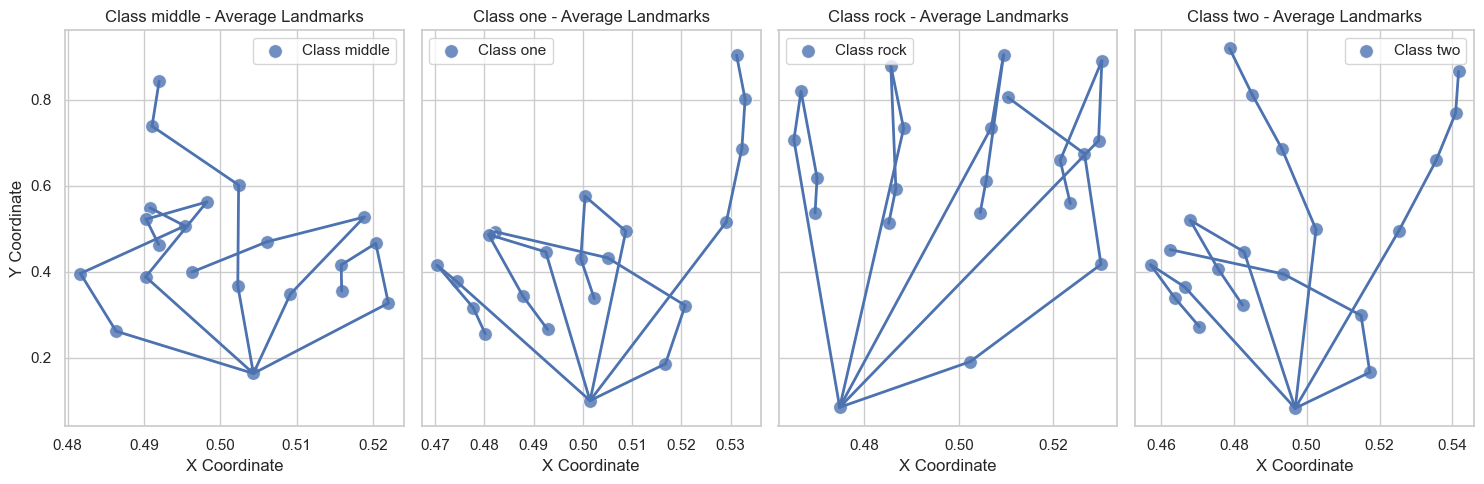

Plotting complete!


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv("gesture_landmarks.csv")

# Convert all landmark columns to numeric to avoid dtype issues
df.iloc[:, :-1] = df.iloc[:, :-1].apply(pd.to_numeric, errors='coerce')

# Get the unique classes
classes = df['label'].unique()

# Set up the Seaborn style for the plot
sns.set(style="whitegrid")

# Set up the figure and the axes for multiple subplots (one per class)
num_classes = len(classes)
fig, axes = plt.subplots(1, num_classes, figsize=(15, 5), sharey=True)

# If there is only one class, 'axes' will not be an array, so we wrap it in a list
if num_classes == 1:
    axes = [axes]

# Iterate over each class and plot the average landmarks in a separate subplot
for i, gesture_class in enumerate(classes):
    ax = axes[i]  # Select the subplot axis for the current class
    
    print(f"Processing class {gesture_class}...")  # Progress indicator
    # Filter data for the current class
    class_data = df[df['label'] == gesture_class]

    # Initialize arrays to store the sum of X and Y coordinates for each class
    sum_x = np.zeros(21)
    sum_y = np.zeros(21)
    
    # Iterate through each sample in the class
    for index, row in class_data.iterrows():
        landmark_data = row[:-1].values  # Excluding the label column

        # Convert to float (fix dtype issue)
        landmark_data = np.array(landmark_data, dtype=np.float64)

        # Reshape the data into (21, 2) since each hand has 21 landmarks with (X, Y) values
        landmarks = landmark_data.reshape(21, 2)

        # Flip the Y-coordinates by subtracting them from 1
        landmarks[:, 1] = 1 - landmarks[:, 1]

        # Add to the sum of X and Y coordinates
        sum_x += landmarks[:, 0]
        sum_y += landmarks[:, 1]
    
    # Calculate the average of X and Y coordinates for the class
    avg_x = sum_x / len(class_data)
    avg_y = sum_y / len(class_data)

    # Plot the average landmarks for the class on the current subplot
    sns.scatterplot(x=avg_x, y=avg_y, label=f"Class {gesture_class}", s=100, marker='o', ax=ax, alpha=0.8)

    # Optionally, connect key landmarks to mimic hand structure
    connections = [
        (0, 1), (1, 2), (2, 3), (3, 4),  # Thumb
        (0, 5), (5, 6), (6, 7), (7, 8),  # Index finger
        (0, 9), (9, 10), (10, 11), (11, 12),  # Middle finger
        (0, 13), (13, 14), (14, 15), (15, 16),  # Ring finger
        (0, 17), (17, 18), (18, 19), (19, 20)  # Pinky finger
    ]

    for connection in connections:
        x1, y1 = avg_x[connection[0]], avg_y[connection[0]]
        x2, y2 = avg_x[connection[1]], avg_y[connection[1]]
        ax.plot([x1, x2], [y1, y2], "b-", linewidth=2)

    # Set individual subplot properties
    ax.set_title(f"Class {gesture_class} - Average Landmarks")
    ax.set_xlabel("X Coordinate")
    ax.set_ylabel("Y Coordinate")
    ax.legend()

# Adjust layout for better spacing
plt.tight_layout()
plt.show()

print("Plotting complete!")


In [15]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report

# Function to apply multiple random rotations to landmarks
def rotate_landmarks_multiple(landmarks, num_rotations=3):
    """Apply multiple random rotations to the landmark coordinates."""
    num_landmarks = landmarks.shape[0] // 2  # Each landmark has (x, y) coordinates
    landmarks = landmarks.reshape(num_landmarks, 2)  # Reshape into (num_landmarks, 2)

    rotated_samples = []
    for _ in range(num_rotations):
        angle = np.random.uniform(0, 2 * np.pi)  # Random rotation angle in radians
        rotation_matrix = np.array([[np.cos(angle), -np.sin(angle)],
                                    [np.sin(angle), np.cos(angle)]])  # 2D Rotation matrix
        rotated_landmarks = np.dot(landmarks, rotation_matrix)  # Apply rotation
        rotated_samples.append(rotated_landmarks.flatten())  # Flatten and store

    return rotated_samples

# Apply rotation augmentation (generate multiple rotated samples per input)
X_augmented = []
y_augmented = []

for sample, label in zip(X, y):
    rotated_variants = rotate_landmarks_multiple(sample, num_rotations=3)  # Increase rotations
    X_augmented.extend(rotated_variants)  # Add all rotated samples
    y_augmented.extend([label] * len(rotated_variants))  # Duplicate labels accordingly

# Convert lists to numpy arrays
X_augmented = np.array(X_augmented)
y_augmented = np.array(y_augmented)

# Combine original and augmented data
X = np.vstack((X, X_augmented))
y = np.hstack((y, y_augmented))  # Duplicate labels for augmented data


# Identify class to remove
class_to_remove = label_encoder.transform(["two"])[0]  # Get encoded value of "two"

# Filter out class "two" from the dataset
mask = y != class_to_remove  # Keep only samples not labeled as "two"
X_filtered = X[mask]
y_filtered = y[mask]

# Re-encode labels after dropping a class
unique_classes = np.unique(y_filtered)  # Get remaining classes
label_map = {old: new for new, old in enumerate(unique_classes)}  # Map old labels to new indices
y_filtered = np.array([label_map[label] for label in y_filtered])  # Update labels

# Split dataset (70% train, 15% validation, 15% test)
X_train, X_temp, y_train, y_temp = train_test_split(X_filtered, y_filtered, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Normalize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# Define updated MLP model with 3 output classes
model = keras.Sequential([
    layers.Dense(32, activation="relu", input_shape=(X_train.shape[1],), kernel_regularizer=regularizers.l1(lambda_l1)),
    layers.BatchNormalization(),
    layers.Dropout(0.5),

    layers.Dense(16, activation="relu", kernel_regularizer=regularizers.l1(lambda_l1)),
    layers.BatchNormalization(),
    layers.Dropout(0.5),

    layers.Dense(8, activation="relu", kernel_regularizer=regularizers.l1(lambda_l1)),
    layers.BatchNormalization(),
    layers.Dropout(0.5),

    layers.Dense(len(unique_classes), activation="softmax")  # Update output layer to 3 classes
])

# Compile and train the model
model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=1, batch_size=8, callbacks=[early_stopping])

# Save model and scaler
model.save("gesture_mlp_model.h5")
np.save("scaler.npy", scaler.mean_)
np.save("scaler_scale.npy", scaler.scale_)

print("Model training complete. 'gesture_mlp_model.h5' saved.")

# Evaluate on test set
y_pred = model.predict(X_test)
y_pred_labels = np.argmax(y_pred, axis=1)


57090/57090 [==============================] - 356s 6ms/step - loss: 0.8231 - accuracy: 0.7379 - val_loss: 0.3561 - val_accuracy: 0.9191
Model training complete. 'gesture_mlp_model.h5' saved.


In [16]:
print(target_names)
target_names = target_names[0:3]
print(target_names)


['middle', 'one', 'rock']
['middle', 'one', 'rock']


In [17]:
# Generate classification report
target_names = [str(label) for label in label_encoder.classes_]  # Convert to string labels
target_names = target_names[0:3]

report = classification_report(y_test, y_pred_labels, target_names=target_names)
print("\nClassification Report:\n", report)


Classification Report:
               precision    recall  f1-score   support

      middle       0.86      0.95      0.90     32748
         one       0.98      0.88      0.93     32441
        rock       0.94      0.92      0.93     32679

    accuracy                           0.92     97868
   macro avg       0.92      0.92      0.92     97868
weighted avg       0.92      0.92      0.92     97868



In [4]:
import cv2
import mediapipe as mp
import numpy as np
import tensorflow as tf
import joblib
import pyautogui
from sklearn.preprocessing import StandardScaler

# Load trained model and scaler
model = tf.keras.models.load_model("gesture_mlp_model.h5")
scaler = StandardScaler()
scaler.mean_ = np.load("scaler.npy")
scaler.scale_ = np.load("scaler_scale.npy")

# Mediapipe setup
mp_hands = mp.solutions.hands
mp_drawing = mp.solutions.drawing_utils
hands = mp_hands.Hands(static_image_mode=False, max_num_hands=2, min_detection_confidence=0.5, min_tracking_confidence=0.5)

# Gesture to key mapping
gesture_key_map = {
    0: 'h',  
    1: 'w',  
    2: None,   
}

pressed_keys = {key: False for key in gesture_key_map.values()}


def process_landmarks(hand_landmarks):
    """Extracts and normalizes hand landmark coordinates."""
    landmarks = np.array([(lm.x, lm.y) for lm in hand_landmarks.landmark]).flatten()
    return scaler.transform([landmarks])


def press_key(gesture):
    """Handles key press logic."""
    key = gesture_key_map.get(gesture)
    if key and key != 'rock':
        if not pressed_keys[key]:
            pyautogui.keyDown(key)
            pressed_keys[key] = True


def release_keys():
    """Releases all mapped keys."""
    for key, pressed in pressed_keys.items():
        if pressed:
            pyautogui.keyUp(key)
            pressed_keys[key] = False


def compare_hand_averages(left_hand, right_hand, threshold=2):
    """Compares the average landmark values of both hands and presses 'a' or 'd' accordingly."""
    left_avg = np.mean([lm.x + lm.y for lm in left_hand]) if left_hand else None
    right_avg = np.mean([lm.x + lm.y for lm in right_hand]) if right_hand else None
    
    if left_avg is not None and right_avg is not None:
        diff = abs(left_avg - right_avg)
        if diff > threshold:
            if left_avg > right_avg:
                pyautogui.keyDown('a')
                pyautogui.keyUp('d')
            else:
                pyautogui.keyDown('d')
                pyautogui.keyUp('a')
        else:
            pyautogui.keyUp('a')
            pyautogui.keyUp('d')


# Start video capture
cap = cv2.VideoCapture(0)
cv2.namedWindow('Gesture Recognition', cv2.WINDOW_NORMAL)
cv2.setWindowProperty('Gesture Recognition', cv2.WND_PROP_TOPMOST, 1)
while True:
    success, frame = cap.read()
    if not success:
        print("[ERROR] Unable to read from camera. Exiting...")
        break
    
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    results = hands.process(frame_rgb)
    release_keys()
    
    left_hand, right_hand = None, None
    
    if results.multi_hand_landmarks and results.multi_handedness:
        for hand_landmarks, handedness in zip(results.multi_hand_landmarks, results.multi_handedness):
            mp_drawing.draw_landmarks(frame, hand_landmarks, mp_hands.HAND_CONNECTIONS)
            features = process_landmarks(hand_landmarks)
            prediction = model.predict(features)
            gesture = np.argmax(prediction)
            print(f"Raw Prediction: {prediction}, Gesture: {gesture}")

            if gesture != 3:  # Rock gesture does nothing
                press_key(gesture)
            
            if handedness.classification[0].label == "Left":
                left_hand = hand_landmarks.landmark
            else:
                right_hand = hand_landmarks.landmark

    compare_hand_averages(left_hand, right_hand)
    
    cv2.imshow("Gesture Recognition", frame)
    if cv2.waitKey(1) & 0xFF == 27:  # ESC to exit
        break

cap.release()
cv2.destroyAllWindows()
release_keys()


C:\Users\jonk\anaconda3\envs\mp2\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
C:\Users\jonk\anaconda3\envs\mp2\Lib\site-packages\keras\src\optimizers\base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
Raw Prediction: [[0.3246036  0.22329542 0.45210093]], Gesture: 2
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
Raw Prediction: [[0.08572429 0.0426147  0.87166107]], Gesture: 2
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Raw Prediction: [[0.09882572 0.04859767 0.85257655]], Gesture: 2
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
Raw Prediction: [[0.0931577  0.04597906 0.86086327]], Gesture: 2
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Raw Prediction: [[0.09151043 0.04523589 0.86325365]], Gesture: 2
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
Raw Prediction: [[0.09708636 0.04784283 0.8550708 ]], Gesture: 2
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
Raw Prediction: [[0.10325097 0.05072298 0.84602606]], Gesture: 2
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
Raw Prediction: [[0.10850433 0.05320349 0.8382922 ]], Gesture: 2
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Raw Prediction: [[0.11097585 0.05444314 0.8345811 ]], Gesture: 2
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
Raw Prediction: [[0.11931371 0.0606

In [3]:
import tensorflow as tf
import os
import random

# Dataset directory (update this path)
dataset_path = r"C:\Users\jonk\Documents\School\Foundation of AI\Assignment 2\hand images"hh

# Image parameters
img_size = (224, 224)  # Resize images
output_dir = "tfrecords"  # Directory to save TFRecords

# Create output directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

# Get file paths and labels
class_names = sorted(os.listdir(dataset_path))
file_paths, labels = [], []

for i, class_name in enumerate(class_names):
    class_dir = os.path.join(dataset_path, class_name)
    image_files = [os.path.join(class_dir, img) for img in os.listdir(class_dir)]
    file_paths.extend(image_files)
    labels.extend([i] * len(image_files))  # Assign numeric labels

# Shuffle dataset
data = list(zip(file_paths, labels))
random.shuffle(data)
file_paths, labels = zip(*data)

# Split dataset (76% train, 9% val, 15% test)
total_size = len(file_paths)
train_size = int(0.76 * total_size)
val_size = int(0.09 * total_size)

train_files, train_labels = file_paths[:train_size], labels[:train_size]
val_files, val_labels = file_paths[train_size:train_size + val_size], labels[train_size:train_size + val_size]
test_files, test_labels = file_paths[train_size + val_size:], labels[train_size + val_size:]

print(f"Train: {len(train_files)}, Val: {len(val_files)}, Test: {len(test_files)}")

# Function to serialize image and label
def serialize_example(image_path, label):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, img_size)
    image = tf.cast(image, tf.uint8)

    feature = {
        "image": tf.train.Feature(bytes_list=tf.train.BytesList(value=[tf.io.encode_jpeg(image).numpy()])),
        "label": tf.train.Feature(int64_list=tf.train.Int64List(value=[label])),
    }
    example = tf.train.Example(features=tf.train.Features(feature=feature))
    return example.SerializeToString()

# Function to write TFRecord file
def write_tfrecord(file_paths, labels, filename):
    with tf.io.TFRecordWriter(os.path.join(output_dir, filename)) as writer:
        for img_path, label in zip(file_paths, labels):
            example = serialize_example(img_path, label)
            writer.write(example)

# Convert datasets to TFRecords
write_tfrecord(train_files, train_labels, "train.tfrecord")
write_tfrecord(val_files, val_labels, "val.tfrecord")
write_tfrecord(test_files, test_labels, "test.tfrecord")

print("TFRecord files created successfully!")


Train: 101270, Val: 11992, Test: 19988
TFRecord files created successfully!


In [6]:
# Function to parse TFRecord
def parse_tfrecord(example_proto):
    feature_description = {
        "image": tf.io.FixedLenFeature([], tf.string),
        "label": tf.io.FixedLenFeature([], tf.int64),
    }
    parsed = tf.io.parse_single_example(example_proto, feature_description)
    
    image = tf.io.decode_jpeg(parsed["image"], channels=3)
    image = tf.image.resize(image, (224, 224)) / 255.0  # Normalize
    label = tf.cast(parsed["label"], tf.int32)
    return image, label

# Function to load dataset from TFRecord
def load_dataset(tfrecord_file, batch_size=32, shuffle=True):
    dataset = tf.data.TFRecordDataset(tfrecord_file) \
        .map(parse_tfrecord, num_parallel_calls=tf.data.AUTOTUNE)

    if shuffle:
        dataset = dataset.shuffle(1000)
    
    dataset = dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return dataset

# Load train, val, and test datasets
batch_size = 32
train_ds = load_dataset("tfrecords/train.tfrecord", batch_size)
val_ds = load_dataset("tfrecords/val.tfrecord", batch_size, shuffle=False)
test_ds = load_dataset("tfrecords/test.tfrecord", batch_size, shuffle=False)

print("Datasets loaded successfully!")


Datasets loaded successfully!


In [12]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Load pre-trained ResNet50 as the base model
base_model = keras.applications.ResNet50(
    include_top=False,  # Remove the classification head
    input_shape=(224, 224, 3),
    weights="imagenet"
)

# Freeze the base model (optional)
base_model.trainable = False

# Create new classification head
model = keras.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),  # Reduce spatial dimensions
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.BatchNormalization(),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.5),
    layers.BatchNormalization(),
    layers.Dense(32, activation="relu"),
    layers.Dropout(0.5),
    layers.BatchNormalization(),
    layers.Dense(len(class_names), activation="softmax")  # Output layer
])

# Compile the model
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Train the model
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)]
)

# Save the model
model.save("gesture_resnet_model.h5")
print("Model saved as gesture_resnet_model.h5")


Epoch 1/10
3165/3165 [==============================] - 360s 112ms/step - loss: 1.6671 - accuracy: 0.2545 - val_loss: 1.3886 - val_accuracy: 0.2448
Epoch 2/10
3165/3165 [==============================] - 362s 114ms/step - loss: 1.4553 - accuracy: 0.2560 - val_loss: 1.3835 - val_accuracy: 0.2814
Epoch 3/10
3165/3165 [==============================] - 355s 112ms/step - loss: 1.4024 - accuracy: 0.2624 - val_loss: 1.3834 - val_accuracy: 0.2814
Epoch 4/10
3165/3165 [==============================] - 346s 109ms/step - loss: 1.3890 - accuracy: 0.2716 - val_loss: 1.3834 - val_accuracy: 0.2814
Epoch 5/10
3165/3165 [==============================] - 348s 109ms/step - loss: 1.3845 - accuracy: 0.2809 - val_loss: 1.3836 - val_accuracy: 0.2814
Epoch 6/10
2814/3165 [=========================>....] - ETA: 34s - loss: 1.3836 - accuracy: 0.2849

KeyboardInterrupt: 

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Evaluate on test set
y_pred = model.predict(X_test)
y_pred_labels = np.argmax(y_pred, axis=1)

# Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred_labels, target_names=label_encoder.classes_))

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred_labels)

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()


In [15]:
import cv2
import mediapipe as mp
import numpy as np
import pyautogui

# Mediapipe setup
mp_hands = mp.solutions.hands
mp_drawing = mp.solutions.drawing_utils
hands = mp_hands.Hands(static_image_mode=False, max_num_hands=2, min_detection_confidence=0.5, min_tracking_confidence=0.5)

# Key press tracking
pressed_keys = {'w': False, 's': False, 'h': False, 'a': False, 'd': False}

# Adjustable thresholds
thumb_proximity_threshold = 0.10  # Threshold for thumb proximity check
straight_line_tolerance = 2 # Tolerance for detecting straight fingers
left_right_hand_threshold = 0.15  # Threshold for A/D movement detection

# Buffer delay for key release
gesture_buffer_frames = 5  # Number of frames to wait before releasing the key after gesture is no longer detected
gesture_inactive_counter = {'w': 0, 's': 0, 'h': 0, 'a': 0, 'd': 0}  # Track inactivity for each key

def release_keys():
    """Releases all mapped keys."""
    for key in pressed_keys:
        if pressed_keys[key] and gesture_inactive_counter[key] >= gesture_buffer_frames:
            pyautogui.keyUp(key)
            pressed_keys[key] = False

def press_key(key):
    """Handles key press logic."""
    if not pressed_keys[key]:
        pyautogui.keyDown(key)
        pressed_keys[key] = True

def is_almost_straight_ordered(line_points, tolerance=straight_line_tolerance):
    """Checks if a set of points forms a nearly straight line in order."""
    x_coords, y_coords = zip(*line_points)
    if not (all(x1 <= x2 for x1, x2 in zip(x_coords, x_coords[1:])) or all(x1 >= x2 for x1, x2 in zip(x_coords, x_coords[1:]))):
        return False  # Ensure order is maintained
    
    poly = np.polyfit(x_coords, y_coords, 1)  # Fit a line to the points
    residuals = np.abs(np.polyval(poly, x_coords) - y_coords)
    return np.max(residuals) < tolerance

def detect_gesture(hand_landmarks, handedness, frame):
    """Detects predefined gestures based on landmark positions and labels landmarks."""
    landmarks = [(lm.x, lm.y) for lm in hand_landmarks.landmark]
    
    # Release all keys before detecting gestures
    release_keys()

    thumb_points = landmarks[0:5]  # Landmarks 0 to 4 (Thumb)
    middle_points = landmarks[9:13]  # Landmarks 9, 10, 11 (Middle Finger Base)
    
    # Draw labels for each landmark
    h, w, _ = frame.shape
    for i, (x, y) in enumerate(landmarks):
        cv2.putText(frame, str(i), (int(x * w), int(y * h)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)

    # Detect middle finger gesture (if middle finger landmarks form a nearly straight line in order)
    if is_almost_straight_ordered(middle_points):
        print("Middle Finger Gesture Detected!")
        press_key('h')  # Middle finger gesture -> H
        return

    # Check if thumb tip (4) is near index finger base (6), treat as no gesture
    if np.linalg.norm(np.array(landmarks[4]) - np.array(landmarks[6])) < thumb_proximity_threshold:
        return

    # Detect thumbs up (if thumb landmarks form a nearly straight line in order)
    if is_almost_straight_ordered(thumb_points):
        if handedness == "Left":
            press_key('w')  # Right hand thumbs up -> W
        elif handedness == "Right":
            press_key('s')  # Left hand thumbs up -> S
        return


    # No recognized gesture, release all keys
    release_keys()

def compare_hand_averages(left_hand, right_hand, threshold=left_right_hand_threshold):
    """Compares the y-coordinate of landmark 0 for left-right movement."""
    if left_hand and right_hand:
        left_y = left_hand[0].y  # Y coordinate of landmark 0 (wrist) of left hand
        right_y = right_hand[0].y  # Y coordinate of landmark 0 (wrist) of right hand
        
        diff = abs(left_y - right_y)
        if diff > threshold:
            if left_y > right_y:
                press_key('d')
                pyautogui.keyUp('a')
            else:
                press_key('a')
                pyautogui.keyUp('d')
        else:
            pyautogui.keyUp('a')
            pyautogui.keyUp('d')

# Start video capture
cap = cv2.VideoCapture(0)

# Create named window for PiP with window flag to stay on top
cv2.namedWindow('Gesture Recognition', cv2.WINDOW_NORMAL)
cv2.setWindowProperty('Gesture Recognition', cv2.WND_PROP_TOPMOST, 1)

while True:
    success, frame = cap.read()
    if not success:
        print("[ERROR] Unable to read from camera. Exiting...")
        break
    
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    results = hands.process(frame_rgb)
    
    # Update inactive counters for each key
    for key in pressed_keys:
        if pressed_keys[key]:
            gesture_inactive_counter[key] += 1
        else:
            gesture_inactive_counter[key] = 0

    # Initialize hands as None
    left_hand, right_hand = None, None
    
    if results.multi_hand_landmarks and results.multi_handedness:
        for hand_landmarks, handedness in zip(results.multi_hand_landmarks, results.multi_handedness):
            mp_drawing.draw_landmarks(frame, hand_landmarks, mp_hands.HAND_CONNECTIONS)
            detect_gesture(hand_landmarks, handedness.classification[0].label, frame)
            
            if handedness.classification[0].label == "Left":
                left_hand = hand_landmarks.landmark
            else:
                right_hand = hand_landmarks.landmark
    
    compare_hand_averages(left_hand, right_hand, threshold=left_right_hand_threshold)
    
    # Display the video feed in a floating PiP window
    cv2.imshow("Gesture Recognition", frame)

    if cv2.waitKey(1) & 0xFF == 27:  # ESC to exit
        break

cap.release()
cv2.destroyAllWindows()
release_keys()


Middle Finger Gesture Detected!
Middle Finger Gesture Detected!
Middle Finger Gesture Detected!
Middle Finger Gesture Detected!
Middle Finger Gesture Detected!
Middle Finger Gesture Detected!
Middle Finger Gesture Detected!
Middle Finger Gesture Detected!
Middle Finger Gesture Detected!
Middle Finger Gesture Detected!
Middle Finger Gesture Detected!
Middle Finger Gesture Detected!
Middle Finger Gesture Detected!
Middle Finger Gesture Detected!


In [3]:
import cv2
print(cv2.getBuildInformation())



General configuration for OpenCV 4.11.0 =====================================
  Version control:               4.11.0

  Extra modules:
    Location (extra):            D:/a/opencv-python/opencv-python/opencv_contrib/modules
    Version control (extra):     4.11.0

  Platform:
    Timestamp:                   2025-01-16T09:56:43Z
    Host:                        Windows 10.0.17763 AMD64
    CMake:                       3.24.2
    CMake generator:             Visual Studio 14 2015
    CMake build tool:            MSBuild.exe
    MSVC:                        1900
    Configuration:               Debug Release
    Algorithm Hint:              ALGO_HINT_ACCURATE

  CPU/HW features:
    Baseline:                    SSE SSE2 SSE3
      requested:                 SSE3
    Dispatched code generation:  SSE4_1 SSE4_2 AVX FP16 AVX2
      requested:                 SSE4_1 SSE4_2 AVX FP16 AVX2 AVX512_SKX
      SSE4_1 (16 files):         + SSSE3 SSE4_1
      SSE4_2 (1 files):          + SSSE3 SSE4_

In [6]:
import cv2
import numpy as np

# Check if CUDA is available
print("CUDA available: ", cv2.cuda.getCudaEnabledDeviceCount() > 0)


CUDA available:  False
